# **Analisis General**

El siguiente planteamiento tecnico responde a la necesidad de implementar una solucion escalable basada en la nube que permita integrar informacion proveniente de diversas fuentes, gestionar grandes volumenes de datos en crecimiento constante y permitir una mejora en la toma de decisiones con informacion confiable y actualizada.

## **Descripcion general de la solucion**

Se opto por diseñar una arquitectura de procesamiento ***`Lambda`*** ya que es una solución híbrida que combina procesamiento en batch y en streaming, lo que permite en este caso hacer un monitoreo del clima en tiempo real y un analisis de la evolucion historica mas exhaustiva. Ademas se opto por la arquitectura de trabajo ***`Medallon`*** y una arquitectura de almacenamiento del tipo ***`Data Lake`***, separando los datos en las capas de *Bronze*, *Silver* y *Gold*.

El proceso cuenta con una carga inicial de datos historicos realizada con scripts de *Python*, y una carga calendarizada desde un conector de *Airbyte* hacia una API de clima (*Openweather*) que corre por cada hora. Los datos se cargan inicialmente en el bucket de Bronze. Luego son procesados en batch mediante scripts de *Apache Spark* generando particiones por region y fecha. Finalmente son consumidos desde *AWS Athena* para consultar los archivos mediante SQL estandar y responder las preguntas de negocio. 

Toda la arquitectura principal esta orquestada por *Apache Airflow* a traves de una ejecucion diaria a las *00:00 hs*. Tambien se implemento un flujo CI/CD con *GitHub Actions* para validar la integridad y la buena practica del codigo en los scripts. 

Las capas del Data Lake corresponden a buckets en *AWS S3*. Tanto Apache Airflow como Apache Spark corren en contenedores docker separados dentro de distintas instancias de *AWS EC2*. De esta forma queda toda la infraestructura montada en AWS.

---

## **Diagrama de la solucion**

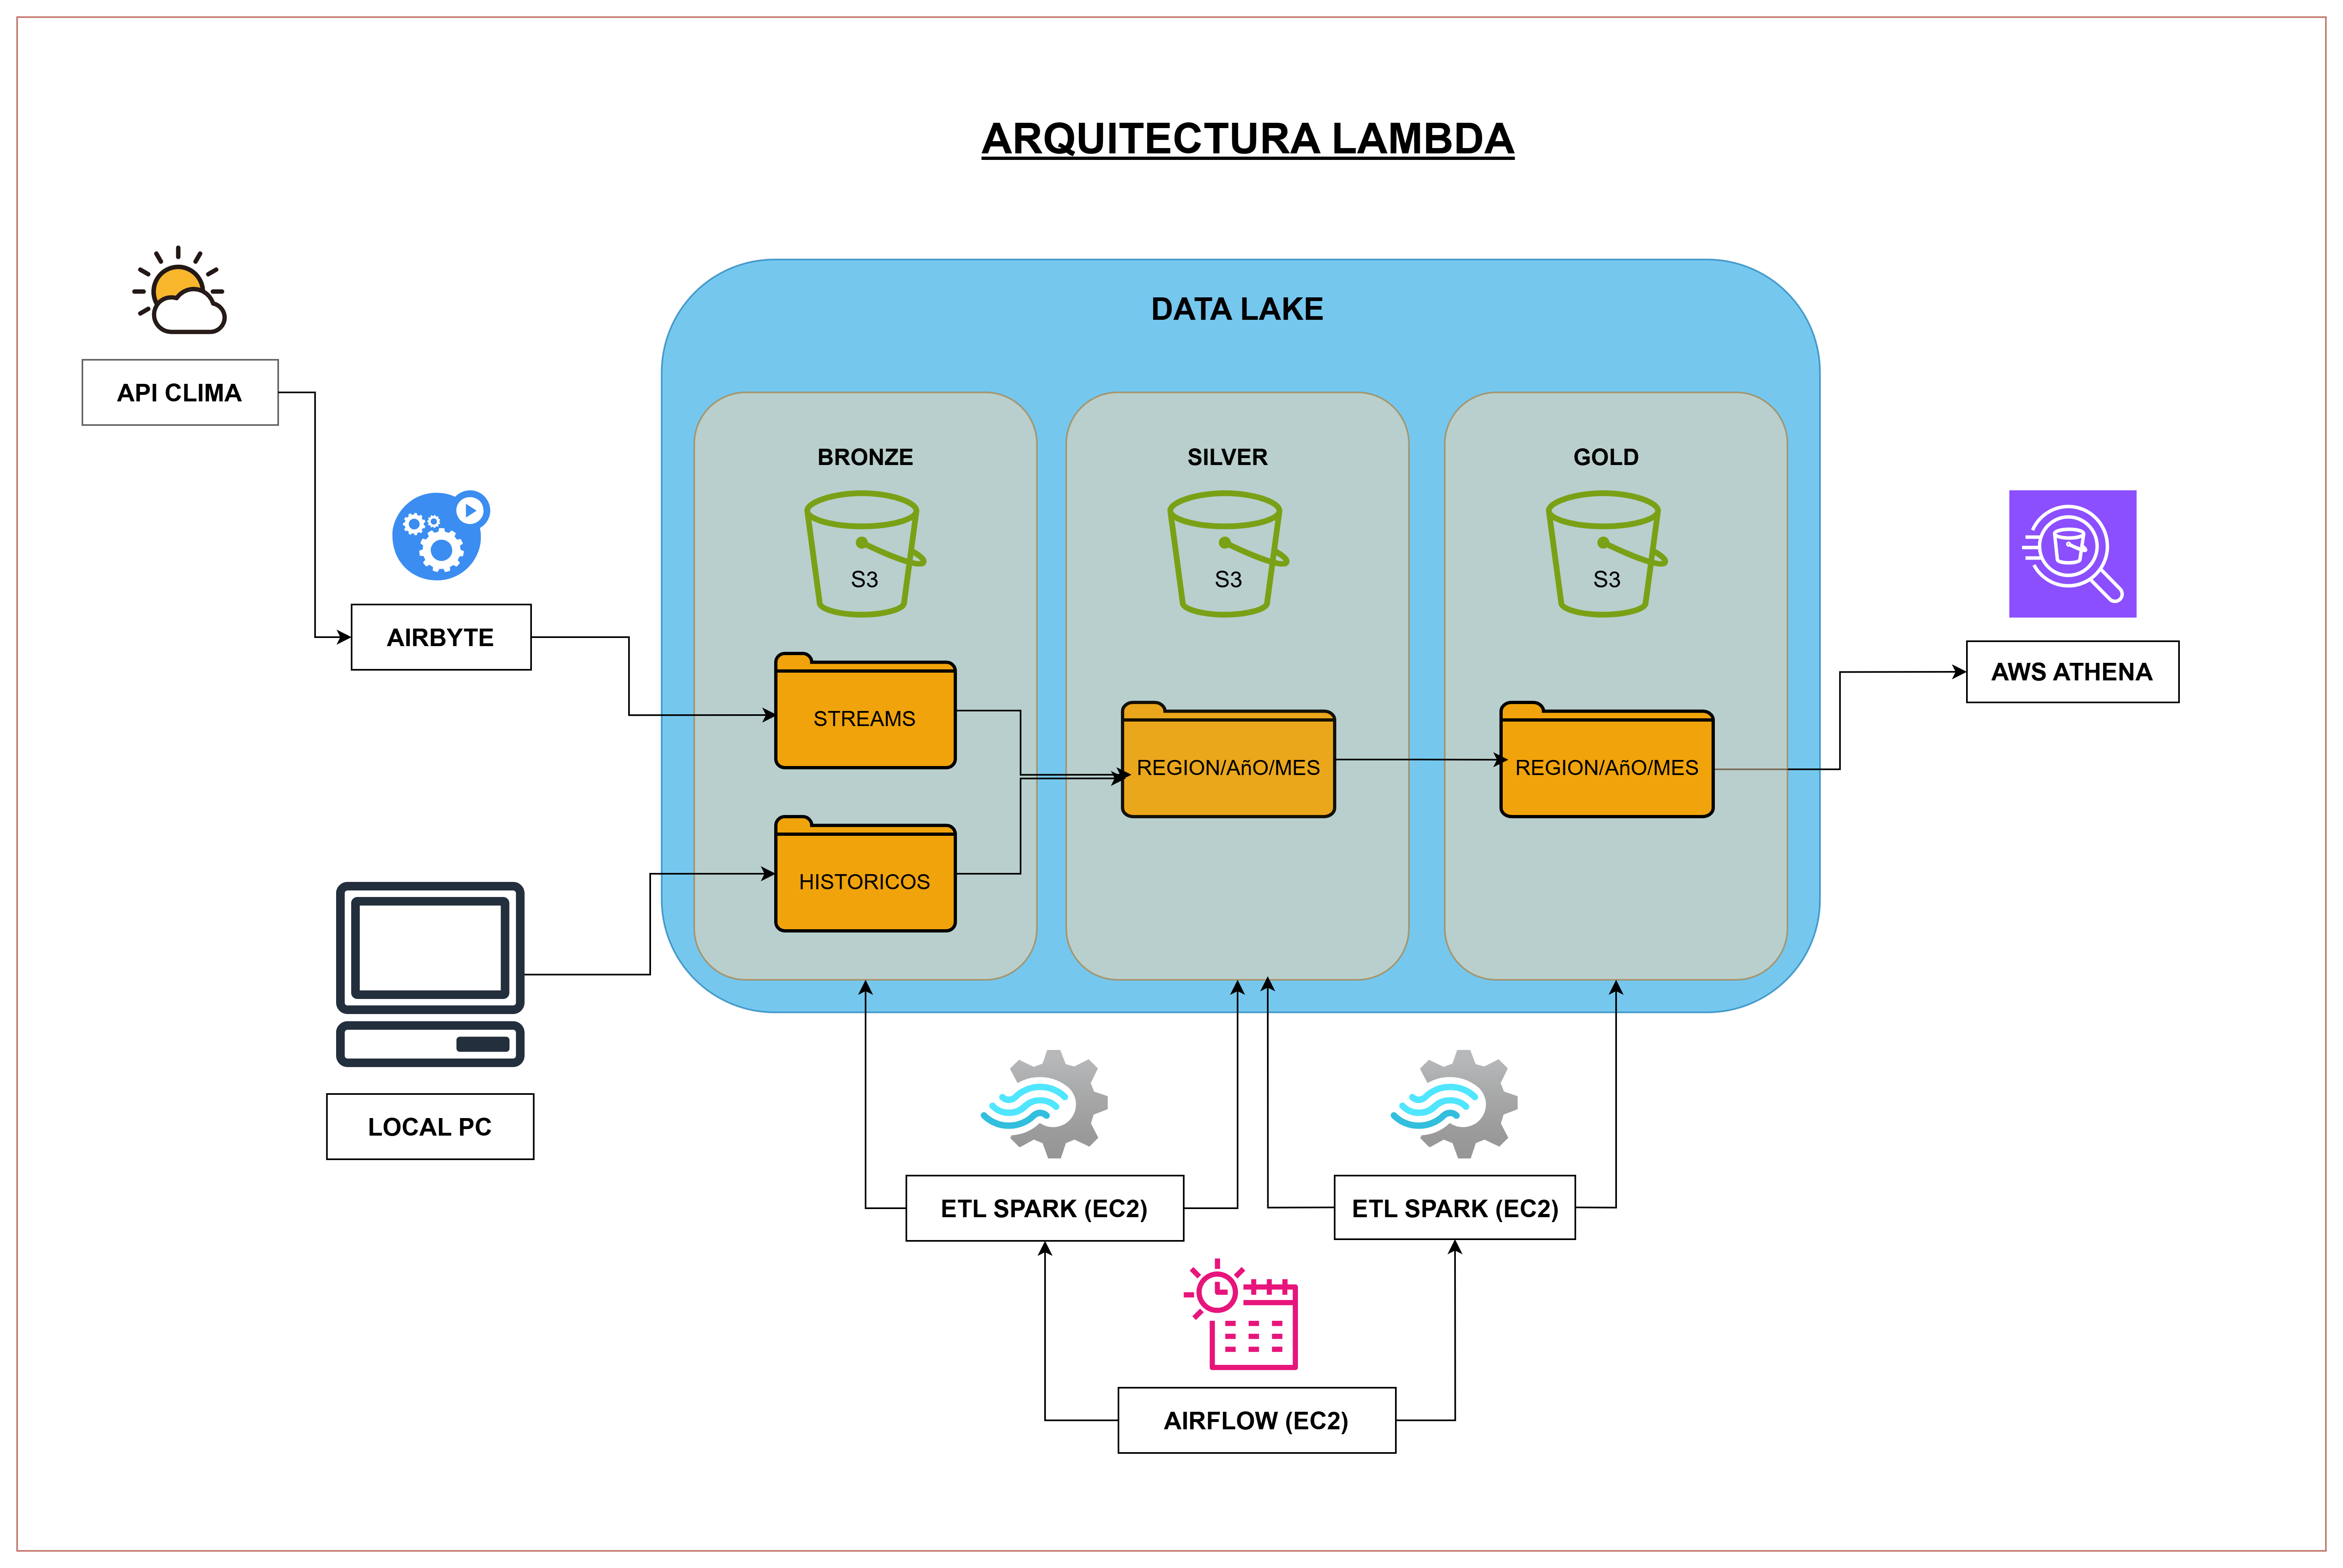

---

## 🛠️**Justificación del Stack Tecnológico**

La selección de tecnologías responde a la necesidad de procesar grandes volúmenes de datos (Big Data) de forma escalable, eficiente en costos y automatizada.

### **Amazon S3 (Data Lake)**

- **Justificación:** Se eligió como el "corazón" del sistema por su durabilidad del 99.999999999% y su bajo costo. Al ser un almacenamiento de objetos, permite separar el *cómputo del almacenamiento*, escalando cada uno de forma independiente.

- **Ventaja:** Permite el uso de formatos abiertos como *Parquet*, facilitando la integración con múltiples motores de consulta.

### **Apache Spark (Motor de Procesamiento)**

- **Justificación:** Spark es el estándar de la industria para procesamiento distribuido. Su capacidad de manejar transformaciones complejas en memoria (In-Memory Computing) lo hace ideal para los cálculos físicos de potencial energético.

- **Optimización:** El uso de *Docker* para el clúster Spark garantiza un entorno reproducible, evitando conflictos de librerías entre capas.

### **Apache Airflow (Orquestación)**

- **Justificación:** Se utiliza para gestionar el flujo de trabajo mediante *DAGs (Grafos Acíclicos Dirigidos)*. A diferencia de un simple `cron`, Airflow permite manejar reintentos, dependencias entre tareas y visibilidad de fallos en tiempo real.

- **Estrategia:** Se implementó una programación *@daily* para asegurar que la capa Gold siempre tenga los datos consolidados del día anterior.

### **Amazon Athena (Query Engine)**

- **Justificación:** Es un servicio *serverless* (sin servidor) basado en Trino/Presto. No requiere mantener una base de datos encendida 24/7, lo que reduce costos drásticamente. Solo se paga por los datos escaneados en S3.



---

## **Detalle de las Capas en S3 (Medallion Architecture)**

El Bucket `m4-pi-medallion` está organizado para garantizar la trazabilidad del dato:

### **📂 Capa Bronze (Raw / Crudo)**

- **Rutas:** bronze/historicos/ y bronze/streams/

- **Formato:** JSON.

- **Descripción:** Contiene los datos tal cual llegan de la API de OpenWeather. No se aplica ninguna transformación. Es la fuente de verdad en caso de que necesitemos reprocesar todo el pipeline.

### **📂 Capa Silver (Trusted / Normalizada)**

- **Ruta:** silver/weather_unified_parquet/

- **Formato:** Parquet (Comprimido con Snappy).

- **Descripción:** Los datos han sido limpiados y unificados. Se eliminaron columnas irrelevantes, se castearon los tipos de datos (Long, Double, Integer) y se normalizaron las coordenadas de Patagonia y Riohacha. Está particionada por *region/year/month* para optimizar la lectura.


### **📂 Capa Gold (Refined / Negocio)**

- **Ruta:** gold/metrics/

- **Formato:** Parquet (Comprimido con Snappy).

- **Descripción:** Es la capa final de consumo. Aquí se encuentran las columnas de *Potencial Solar (W)* y *Potencial Eólico (W)* calculadas. Es la tabla que consulta *Amazon Athena* para generar los reportes de variabilidad energética.

---

## **Optimización de Almacenamiento y Cómputo**

**Formato Columnar (Parquet):** Se seleccionó sobre CSV para reducir el I/O (entrada/salida). Athena solo lee las columnas solicitadas, lo que acelera las consultas un 300% y reduce costos de escaneo de S3.

**Particionado Estratégico:** Al particionar por `region`, las consultas que filtran por "Patagonia" ignoran físicamente los archivos de "Riohacha", optimizando el rendimiento.
